In [31]:
import subprocess
import re
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt

In [32]:
# --- Metadata from your image ---
# Cross-sections in fb
metadata = [
    {"Mass": 1000, "Rinv": 2, "XS": 9551.0},
    {"Mass": 1000, "Rinv": 4, "XS": 9540.0},
    {"Mass": 1000, "Rinv": 6, "XS": 9552.0},
    {"Mass": 1000, "Rinv": 8, "XS": 9554.0},
    {"Mass": 2000, "Rinv": 2, "XS": 146.3},
    {"Mass": 2000, "Rinv": 4, "XS": 146.8},
    {"Mass": 2000, "Rinv": 6, "XS": 146.1},
    {"Mass": 2000, "Rinv": 8, "XS": 145.3},
    {"Mass": 3000, "Rinv": 2, "XS": 14.24},
    {"Mass": 3000, "Rinv": 4, "XS": 14.2},
    {"Mass": 3000, "Rinv": 6, "XS": 14.21},
    {"Mass": 3000, "Rinv": 8, "XS": 14.26},
]
df_meta = pd.DataFrame(metadata)

# --- Configuration ---
LUMI = 139  # Total Integrated Luminosity in fb^-1
input_base = "/home/aegis/ether/replicate_deepak"
output_base = "/home/aegis/ether/Research_HEP/NRAD/Signal/replicate_atlas"


In [33]:
# Chosen modes for specialized plotting
target_modes = ['1000_6', '1000_8', '2000_4', '2000_6', '3000_2', '3000_4']

all_results = []

for item in metadata:
    tag = f"{item['Mass']}_{item['Rinv']}"
    input_file = f"{input_base}/{tag}_events_markXI.root"
    output_file = f"{output_base}/{tag}_events_markXI.txt"
    
    # Run ROOT Analyzer (Applies SR cuts directly)
    root_cmd = f'Analyzer.C("{input_file}","{output_file}")'
    result = subprocess.run(["root", "-l", "-b", "-q", root_cmd], capture_output=True, text=True)
    
    # Extract stats from stdout
    initial = re.search(r"Chain contains (\d+) events", result.stdout)
    selected = re.search(r"Selected events: (\d+)", result.stdout)
    
    if initial and selected:
        n_ini, n_sel = int(initial.group(1)), int(selected.group(1))
        eff = n_sel / n_ini if n_ini > 0 else 0
        yield_val = item['XS'] * LUMI * eff
        
        all_results.append({
            "Mode": tag, "Mass": item['Mass'], "Rinv": item['Rinv'], "XS_fb": item['XS'], "Initial": n_ini, "SR_selected": n_sel,
            "Eff": eff, "Yield": yield_val,"Is_Target": tag in target_modes
        })
        # print(f"{tag:<10} | {eff:.4%} | {yield_val:.2f}")

df_all = pd.DataFrame(all_results)

In [34]:
df_all

,Mode,Mass,Rinv,XS_fb,Initial,SR_selected,Eff,Yield,Is_Target
0,1000_2,1000,2,9551.00,0,0,0.00000,0.000000,False
1,1000_4,1000,4,9540.00,0,0,0.00000,0.000000,False
2,1000_6,1000,6,9552.00,100000,13013,0.13013,172777.244640,True
3,1000_8,1000,8,9554.00,100000,17427,0.17427,231431.605620,True
4,2000_2,2000,2,146.30,0,0,0.00000,0.000000,False
5,2000_4,2000,4,146.80,100000,20194,0.20194,4120.626088,True
6,2000_6,2000,6,146.10,100000,30193,0.30193,6131.564247,True
7,2000_8,2000,8,145.30,0,0,0.00000,0.000000,False
8,3000_2,3000,2,14.24,100000,5037,0.05037,99.700363,True
9,3000_4,3000,4,14.20,100000,10186,0.10186,201.051268,True


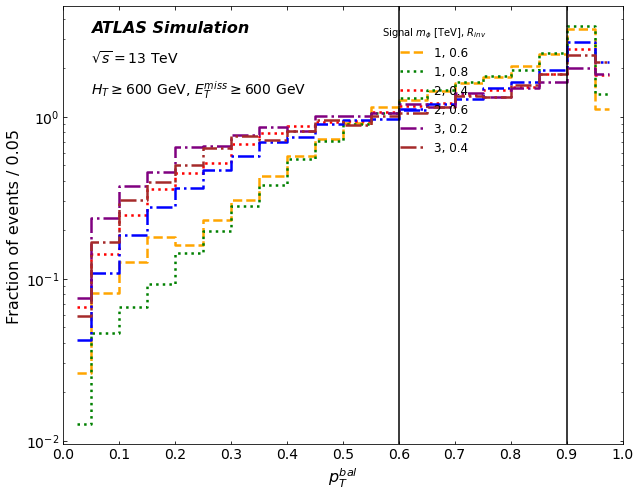

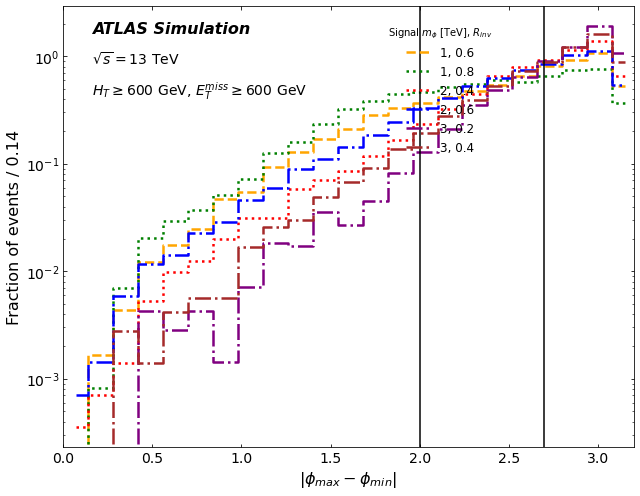

In [35]:
cols = ["pT_j1", "eta_j1", "phi_j1", "pT_j2", "eta_j2", "phi_j2", "m_jj", "sm_jj", 
        "tau21_j1", "tau21_j2", "tau32_j1", "tau32_j2", "met", "phi_met", 
        "min_dPhi", "ht", "pt_balance", "delta_phi_j1j2", "weight"]

styles = {
    '1000_6': ('orange', '--'), '1000_8': ('green', ':'),
    '2000_4': ('red', ':'),    '2000_6': ('blue', '-.'),
    '3000_2': ('purple', '-.'), '3000_4': ('brown', '-.')
}

variables_to_plot = {
    'pt_balance': {
        'bins': np.linspace(0, 1, 21), 'xlabel': r'$p_T^{bal}$',
        'ylabel': 'Fraction of events / 0.05', 'xlim': (0, 1),
        'vlines': [0.6, 0.9], 'xticks': np.arange(0, 1.1, 0.1)
    },
    'delta_phi_j1j2': {
        'bins': np.linspace(0, 3.22, 24), 'xlabel': r'$|\phi_{max} - \phi_{min}|$',
        'ylabel': 'Fraction of events / 0.14', 'xlim': (0, 3.2),
        'vlines': [2.0, 2.7], 'xticks': np.arange(0, 3.5, 0.5)
    }
}

for var_name, config in variables_to_plot.items():
    plt.figure(figsize=(9, 7))
    ax = plt.gca()

    # ONLY loop through chosen target_modes for plotting
    for mode in target_modes:
        path_final = os.path.join(output_base, f"{mode}_events_markXI.txt")
        if not os.path.exists(path_final): continue

        try:
            df_final = pd.read_csv(path_final, sep='\s+', names=cols, skiprows=1)
            
            # Density=True for unit area normalization (shape comparison)
            counts, edges = np.histogram(df_final[var_name], bins=config['bins'], density=True)
            bin_centers = (edges[:-1] + edges[1:]) / 2

            color, linestyle = styles.get(mode, ('black', '-'))
            mass, rinv = mode.split('_')
            label = f"{int(mass)//1000}, {float(rinv)/10}"

            plt.plot(bin_centers, counts, drawstyle='steps-mid', color=color, 
                     linestyle=linestyle, linewidth=2.5, label=label)

        except Exception as e:
            print(f"Error plotting {mode}: {e}")

    # Standard ATLAS Styling Logic
    for vline in config['vlines']:
        plt.axvline(x=vline, color='black', linestyle='-', linewidth=1.5)

    plt.yscale('log')
    # plt.ylim(1e-3, 50) 
    plt.xlim(config['xlim'])
    plt.xlabel(config['xlabel'], fontsize=16)
    plt.ylabel(config['ylabel'], fontsize=16)
    plt.text(0.05, 0.94, 'ATLAS Simulation', transform=ax.transAxes, fontsize=16, fontweight='bold', style='italic')
    plt.text(0.05, 0.87, r'$\sqrt{s} = 13$ TeV', transform=ax.transAxes, fontsize=14)
    plt.text(0.05, 0.80, r'$H_T \geq 600$ GeV, $E_T^{miss} \geq 600$ GeV', transform=ax.transAxes, fontsize=14)
    plt.legend(title=r'Signal $m_{\phi}$ [TeV], $R_{inv}$', loc='upper left', bbox_to_anchor=(0.55, 0.98), frameon=False, fontsize=12)
    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=14)
    plt.xticks(config['xticks'])
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_2199565/1412574090.py:99: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 1e7)


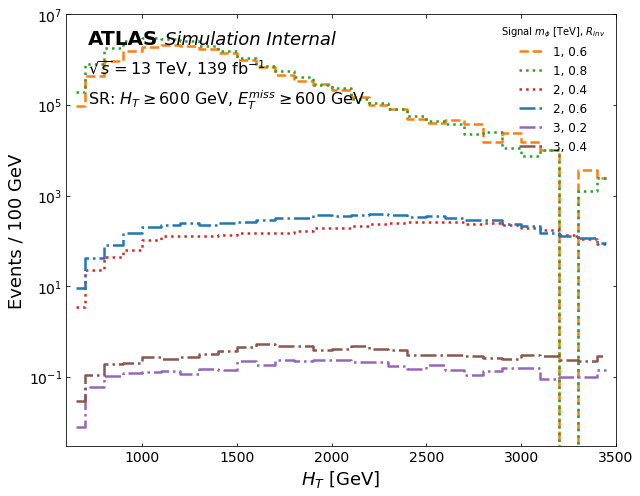

/tmp/ipykernel_2199565/1412574090.py:99: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 1e7)


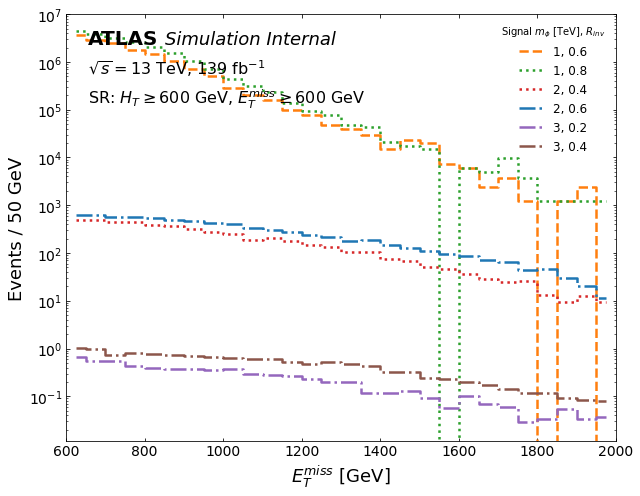

/tmp/ipykernel_2199565/1412574090.py:99: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 1e7)


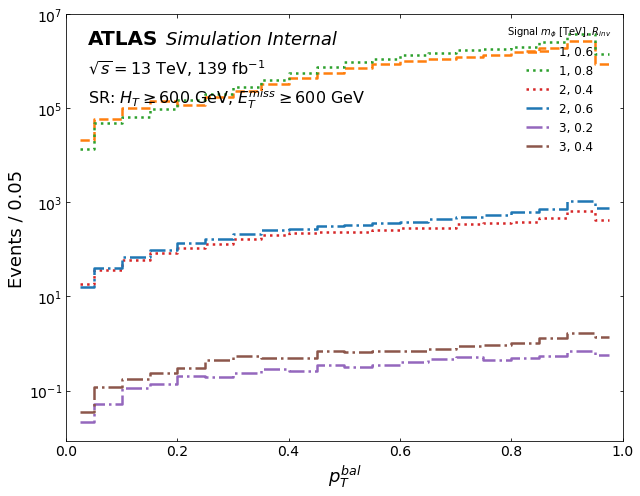

/tmp/ipykernel_2199565/1412574090.py:99: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 1e7)


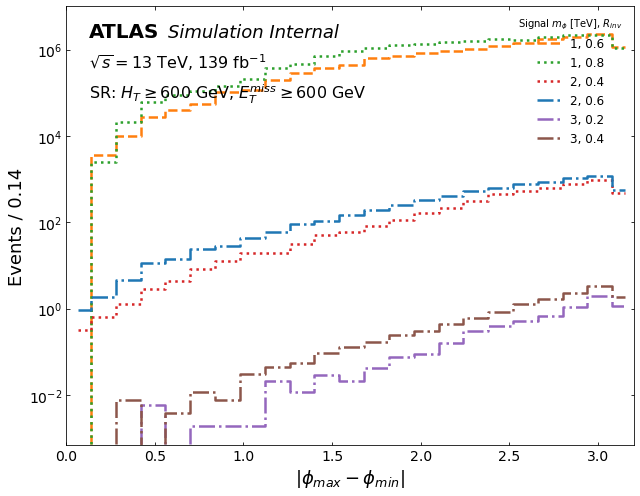

In [36]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# --- Configuration & Styling ---
output_base = "/home/aegis/ether/Research_HEP/NRAD/Signal/replicate_atlas"
target_modes = ['1000_6', '1000_8', '2000_4', '2000_6', '3000_2', '3000_4']

cols = ["pT_j1", "eta_j1", "phi_j1", "pT_j2", "eta_j2", "phi_j2", "m_jj", "sm_jj", 
        "tau21_j1", "tau21_j2", "tau32_j1", "tau32_j2", "met", "phi_met", 
        "min_dPhi", "ht", "pt_balance", "delta_phi_j1j2", "weight"]

styles = {
    '1000_6': ('#ff7f0e', '--'), '1000_8': ('#2ca02c', ':'),
    '2000_4': ('#d62728', ':'),  '2000_6': ('#1f77b4', '-.'),
    '3000_2': ('#9467bd', '-.'), '3000_4': ('#8c564b', '-.')
}

# --- Plotting Dictionary for all 4 reference images ---
variables_to_plot = {
    'ht': {
        'bins': np.linspace(600, 3500, 30),
        'xlabel': r'$H_T$ [GeV]',
        'ylabel': 'Events / 100 GeV',
        'xlim': (600, 3500),
        'vlines': []
    },
    'met': {
        'bins': np.linspace(600, 2000, 29),
        'xlabel': r'$E_T^{miss}$ [GeV]',
        'ylabel': 'Events / 50 GeV',
        'xlim': (600, 2000),
        'vlines': []
    },
    'pt_balance': {
        'bins': np.linspace(0, 1, 21),
        'xlabel': r'$p_T^{bal}$',
        'ylabel': 'Events / 0.05',
        'xlim': (0, 1),
        'vlines': [0.6, 0.9]
    },
    'delta_phi_j1j2': {
        'bins': np.linspace(0, 3.22, 24),
        'xlabel': r'$|\phi_{max} - \phi_{min}|$',
        'ylabel': 'Events / 0.14',
        'xlim': (0, 3.2),
        'vlines': [2.0, 2.7]
    }
}

for var_name, config in variables_to_plot.items():
    plt.figure(figsize=(9, 7))
    ax = plt.gca()

    for mode in target_modes:
        path_final = os.path.join(output_base, f"{mode}_events_markXI.txt")
        if not os.path.exists(path_final): continue

        try:
            # 1. Retrieve the metadata for this specific signal point
            row = df_all[df_all['Mode'] == mode].iloc[0]
            xs = row['XS_fb']       # Cross section from metadata
            n_gen = row['Initial']  # Total events in the chain before cuts
            
            # 2. Load the SR-selected data
            df = pd.read_csv(path_final, sep='\s+', names=cols, skiprows=1)
            
            # 3. Calculate the normalization factor
            # This converts raw weights to the physical number of expected events
            lumi = 139.0
            norm_factor = (xs * lumi) / n_gen
            
            # Apply the factor to the existing weights from the tree
            normalized_weights = df['weight'] * norm_factor

            # 4. Plot as absolute Events (density=False)
            counts, edges = np.histogram(
                df[var_name], 
                bins=config['bins'], 
                weights=normalized_weights, 
                density=False
            )
            bin_centers = (edges[:-1] + edges[1:]) / 2

            color, ls = styles.get(mode, ('black', '-'))
            mass, rinv = mode.split('_')
            label = f"{int(mass)//1000}, {float(rinv)/10 if len(rinv)==1 else float(rinv)/10}"

            plt.plot(bin_centers, counts, drawstyle='steps-mid', color=color, 
                     linestyle=ls, linewidth=2.5, label=label)

        except Exception as e:
            print(f"Error normalizing weights for {mode}: {e}")

    # --- Decorations (ATLAS Style) ---
    plt.yscale('log')
    # Adjust ylim based on your background levels; ATLAS plots go from 1 to 10^7
    plt.ylim(0, 1e7) 
    plt.xlim(config['xlim'])
    plt.xlabel(config['xlabel'], fontsize=18)
    plt.ylabel(config['ylabel'], fontsize=18)
    
    # Standard ATLAS Text
    plt.text(0.04, 0.93, 'ATLAS', transform=ax.transAxes, fontsize=20, fontweight='bold')
    plt.text(0.18, 0.93, 'Simulation Internal', transform=ax.transAxes, fontsize=18, style='italic')
    plt.text(0.04, 0.86, r'$\sqrt{s} = 13$ TeV, $139$ fb$^{-1}$', transform=ax.transAxes, fontsize=16)
    plt.text(0.04, 0.79, r'SR: $H_T \geq 600$ GeV, $E_T^{miss} \geq 600$ GeV', transform=ax.transAxes, fontsize=16)

    plt.legend(title=r'Signal $m_{\phi}$ [TeV], $R_{inv}$', loc='upper right', frameon=False, fontsize=12)
    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=14)
    plt.tight_layout()
    plt.show()

/home/aegis/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


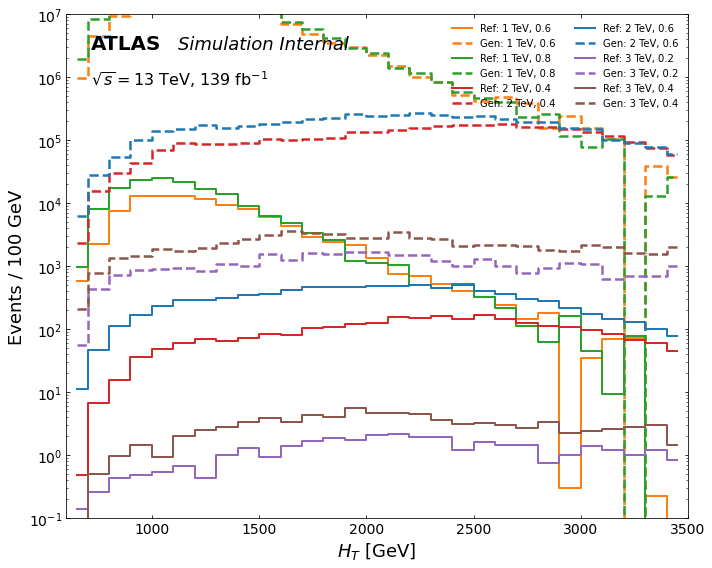

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import io
import os

# --- 1. CONFIGURATION ---
# Path to the downloaded HEPData CSV
hepdata_csv = 'HEPData-HT.csv'

# Your local output directory
output_base = "/home/aegis/ether/Research_HEP/NRAD/Signal/replicate_atlas"

# Modes to compare (Mass_Rinv)
target_modes = ['1000_6', '1000_8', '2000_4', '2000_6', '3000_2', '3000_4']

# Columns for your generated files
cols = ["pT_j1", "eta_j1", "phi_j1", "pT_j2", "eta_j2", "phi_j2", "m_jj", "sm_jj", 
        "tau21_j1", "tau21_j2", "tau32_j1", "tau32_j2", "met", "phi_met", 
        "min_dPhi", "ht", "pt_balance", "delta_phi_j1j2", "weight"]

# Styling: (Color, LineStyle for Regenerated)
# Reference (CSV) will use the SAME color but Solid Line
styles = {
    '1000_6': '#ff7f0e', 
    '1000_8': '#2ca02c',
    '2000_4': '#d62728',  
    '2000_6': '#1f77b4',
    '3000_2': '#9467bd', 
    '3000_4': '#8c564b'
}

# --- 2. HELPER: PARSE HEPDATA CSV ---
def parse_hepdata_csv(filename):
    """Parses the specific stacked CSV format from HEPData."""
    tables = {}
    current_lines = []
    current_name = None
    
    if not os.path.exists(filename):
        print(f"Warning: {filename} not found. Cannot plot reference signals.")
        return {}

    with open(filename, 'r') as f:
        lines = f.readlines()
        
    for line in lines:
        if "Signal" in line or "Total Bkg" in line or "Data [" in line:
            if current_name and current_lines:
                try:
                    csv_io = io.StringIO("".join(current_lines))
                    tables[current_name] = pd.read_csv(csv_io, header=None)
                except: pass
            current_name = line.strip().strip('"').replace(',', '') 
            current_lines = []
        elif line.strip() == "" or line.startswith("source") or line.startswith("#"):
            continue
        elif line[0].isdigit() or line.strip().startswith("HT") or line.strip().startswith("$"):
             if line[0].isdigit():
                 current_lines.append(line)
                 
    if current_name and current_lines:
         csv_io = io.StringIO("".join(current_lines))
         tables[current_name] = pd.read_csv(csv_io, header=None)
    return tables

# --- 3. MAIN PLOTTING LOOP ---
# We focus on HT because that is what is available in the HEPData CSV
var_name = 'ht'
bins = np.linspace(600, 3500, 30) # Matches HEPData binning roughly

# Load Reference Data
ref_data = parse_hepdata_csv(hepdata_csv)

plt.figure(figsize=(10, 8))
ax = plt.gca()

# Iterate over modes to plot both Ref and Gen
for mode in target_modes:
    mass_str, rinv_str = mode.split('_')
    mass_tev = int(mass_str) // 1000
    rinv_val = float(rinv_str) / 10.0
    
    color = styles.get(mode, 'black')
    
    # --- A. PLOT REFERENCE (HEPData) ---
    # Construct the key name as it appears in the CSV (e.g., "Signal (1 TeV R$_{inv}$ 0.6)")
    # Note: The CSV parser removes commas, so we match loosely
    ref_key = None
    search_str = f"Signal ({mass_tev} TeV R$_{{inv}}$ {rinv_val})"
    
    for key in ref_data.keys():
        if f"{mass_tev} TeV" in key and (f"{rinv_val}" in key or str(rinv_val) in key):
            ref_key = key
            break
            
    if ref_key:
        df_ref = ref_data[ref_key]
        # CSV Format: [Center, Low, High, Events, ...]
        ref_x = df_ref[0].values
        ref_y = df_ref[3].values
        
        # Plot Reference as SOLID line
        # Use 'steps-mid' to align with bin centers
        plt.plot(ref_x, ref_y, drawstyle='steps-mid', color=color, 
                 linestyle='-', linewidth=2, label=f"Ref: {mass_tev} TeV, {rinv_val}")
    else:
        print(f"Reference for {mode} not found in CSV.")

    # --- B. PLOT REGENERATED (Your Local Data) ---
    path_final = os.path.join(output_base, f"{mode}_events_markXI.txt")
    
    if os.path.exists(path_final):
        try:
            # Assumes 'df_all' exists in your namespace containing XS/Initial info
            # If not, you must define a dictionary for XS/Init manually
            if 'df_all' in locals() or 'df_all' in globals():
                row = df_all[df_all['Mode'] == mode].iloc[0]
                xs = row['XS_fb']
                n_gen = row['Initial']
            else:
                # Placeholder if df_all is missing
                print(f"Warning: df_all missing for {mode}, using weight=1")
                xs, n_gen = 1.0, 1.0 
                lumi = 1.0

            df_gen = pd.read_csv(path_final, sep='\s+', names=cols, skiprows=1)
            
            lumi = 139.0
            norm_factor = (xs * lumi) / n_gen
            weights = df_gen['weight'] * norm_factor
            
            # Histogram
            counts, edges = np.histogram(df_gen[var_name], bins=bins, weights=weights)
            centers = (edges[:-1] + edges[1:]) / 2
            
            # Plot Regenerated as DASHED line
            plt.plot(centers, counts, drawstyle='steps-mid', color=color, 
                     linestyle='--', linewidth=2.5, label=f"Gen: {mass_tev} TeV, {rinv_val}")
                     
        except Exception as e:
            print(f"Error processing local file for {mode}: {e}")

# --- 4. DECORATIONS ---
plt.yscale('log')
plt.ylim(1e-1, 1e7)
plt.xlim(600, 3500)
plt.xlabel(r'$H_T$ [GeV]', fontsize=18)
plt.ylabel('Events / 100 GeV', fontsize=18)

# ATLAS Styling
plt.text(0.04, 0.93, 'ATLAS', transform=ax.transAxes, fontsize=20, fontweight='bold')
plt.text(0.18, 0.93, 'Simulation Internal', transform=ax.transAxes, fontsize=18, style='italic')
plt.text(0.04, 0.86, r'$\sqrt{s} = 13$ TeV, $139$ fb$^{-1}$', transform=ax.transAxes, fontsize=16)

# Legend
plt.legend(ncol=2, frameon=False, fontsize=10, loc='upper right')
ax.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=14)

plt.tight_layout()
plt.show()